In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [33]:
train = pd.read_csv("../data/raw/train.csv")
store = pd.read_csv("../data/raw/store.csv")

C:\Users\prasa\AppData\Local\Temp\ipykernel_20364\2043513621.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


In [34]:
print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

train.head()

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [35]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [36]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [37]:
print(train.isnull().sum())

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [38]:
print("Train Duplicates:", train.duplicated().sum())
print("Store Duplicates:", store.duplicated().sum())

Train Duplicates: 0
Store Duplicates: 0


In [39]:
df = train.merge(store, on="Store", how="left")

In [40]:
df.shape

(1017209, 18)

In [41]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [42]:
df["Date"] = pd.to_datetime(df["Date"])


In [43]:
df = df.set_index("Date")

In [44]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Date,,,,,,,,,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2015-07-31,2,5,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2015-07-31,3,5,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2015-07-31,4,5,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2015-07-31,5,5,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [45]:
median_distance = df["CompetitionDistance"].median()

df["CompetitionDistance"] = (
    df["CompetitionDistance"]
    .fillna(median_distance)
)

In [46]:
df["CompetitionDistance"].isnull().sum()

np.int64(0)

In [47]:
df = df[df["Open"] == 1]

In [48]:
df.shape

(844392, 17)

In [50]:
weekly_sales = (
    df["Sales"]
    .resample("W")
    .sum()
)

In [51]:
weekly_sales.head()

Date
2013-01-06    26129335
2013-01-13    49275222
2013-01-20    34377765
2013-01-27    46040169
2013-02-03    38466029
Freq: W-SUN, Name: Sales, dtype: int64

In [53]:
weekly_sales.to_csv(
    "../data/processed/weekly_sales.csv"
)

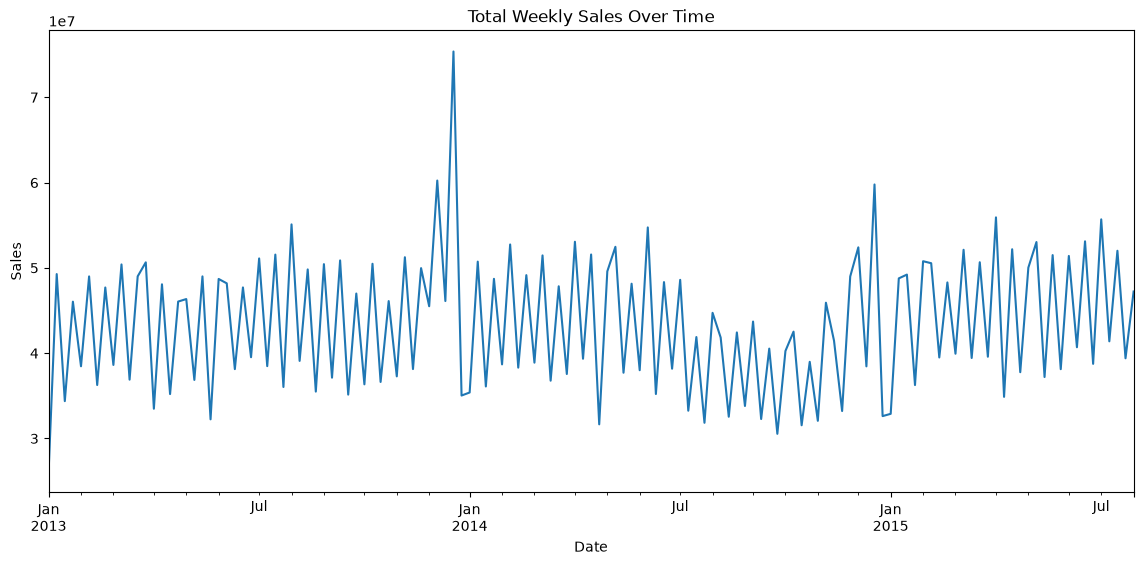

In [55]:
plt.figure(figsize=(14,6))

weekly_sales.plot()

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [56]:
sales_by_day = (
    df.groupby("DayOfWeek")["Sales"]
    .mean()
)

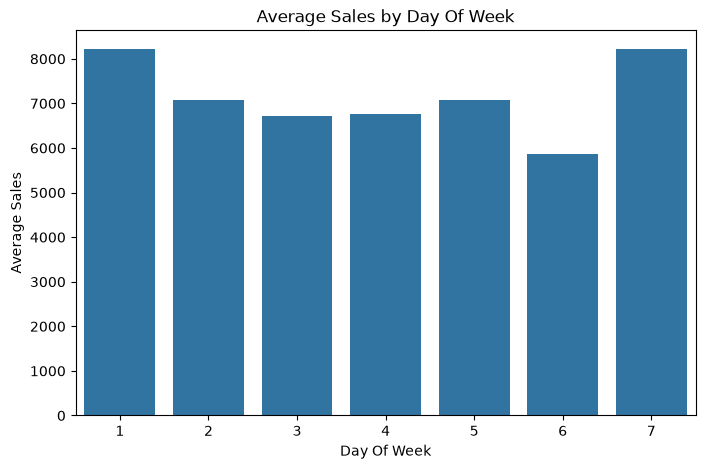

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values
)

plt.title("Average Sales by Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Sales")

plt.show()

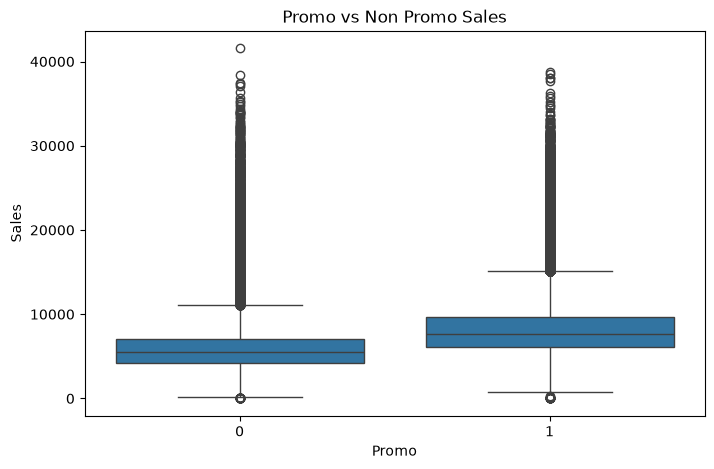

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Promo",
    y="Sales",
    data=df
)

plt.title("Promo vs Non Promo Sales")

plt.show()

In [59]:
top_stores = (
    df.groupby("Store")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

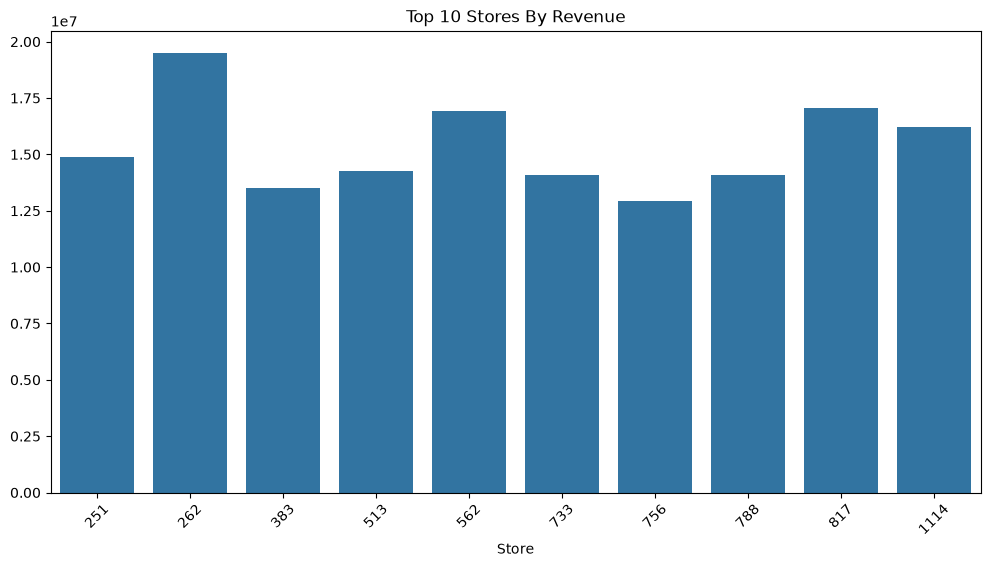

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stores.index,
    y=top_stores.values
)

plt.title("Top 10 Stores By Revenue")

plt.xticks(rotation=45)

plt.show()

In [61]:
print("Mean Sales :", df["Sales"].mean())
print("Median Sales :", df["Sales"].median())
print("Max Sales :", df["Sales"].max())
print("Min Sales :", df["Sales"].min())
print("Std Dev :", df["Sales"].std())

Mean Sales : 6955.514290755952
Median Sales : 6369.0
Max Sales : 41551
Min Sales : 0
Std Dev : 3104.214680428348


In [62]:
stl = STL(
    weekly_sales,
    period=52
)

result = stl.fit()

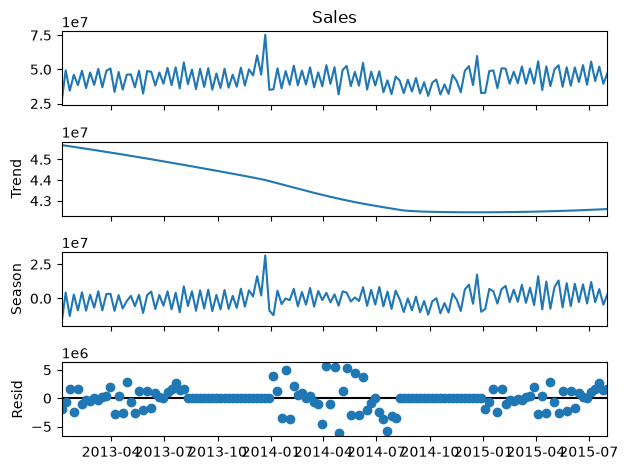

In [63]:
result.plot()

plt.show()

In [64]:
adf_result = adfuller(
    weekly_sales
)

print("ADF Statistic:",
      adf_result[0])

print("P-value:",
      adf_result[1])

ADF Statistic: -3.9019067930454043
P-value: 0.0020208588880313446


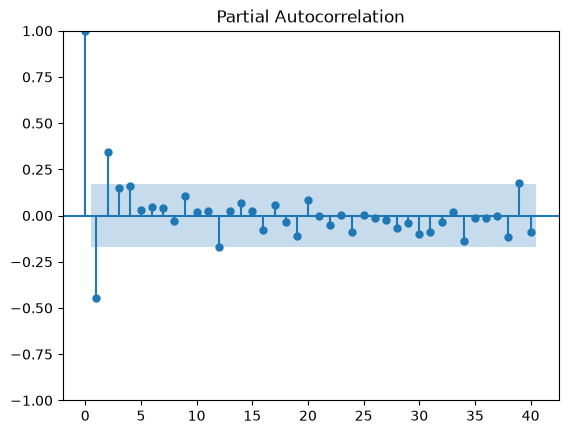

In [67]:
plot_pacf(weekly_sales.dropna(), lags=40)
plt.show()

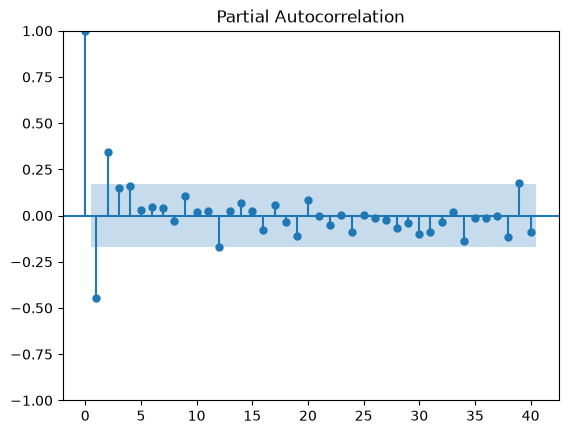

In [69]:
plot_pacf(
    weekly_sales.dropna(),
    lags=40
)

plt.savefig(
    "../dashboard/screenshots/pacf_plot.png",
    bbox_inches="tight"
)

plt.show()